--- Linear Regression Metrics ---
MAE:  $779.52
MSE:  $1066162.86
RMSE: $1032.55
R2 Score: 0.0362

--- Random Forest Metrics ---
MAE:  $733.57
MSE:  $1061665.20
RMSE: $1030.37
R2 Score: 0.0402

--- Dynamic Forecasting ---


Enter Month (1-12):  5
Enter Year (e.g., 2017):  2015
Enter Day of Week (0=Monday, 6=Sunday):  1
Enter Discount (0.0 to 0.5):  0.4



Using Random Forest for prediction (Model R2 score: 0.0402)
Forecasted Sales: $805.31


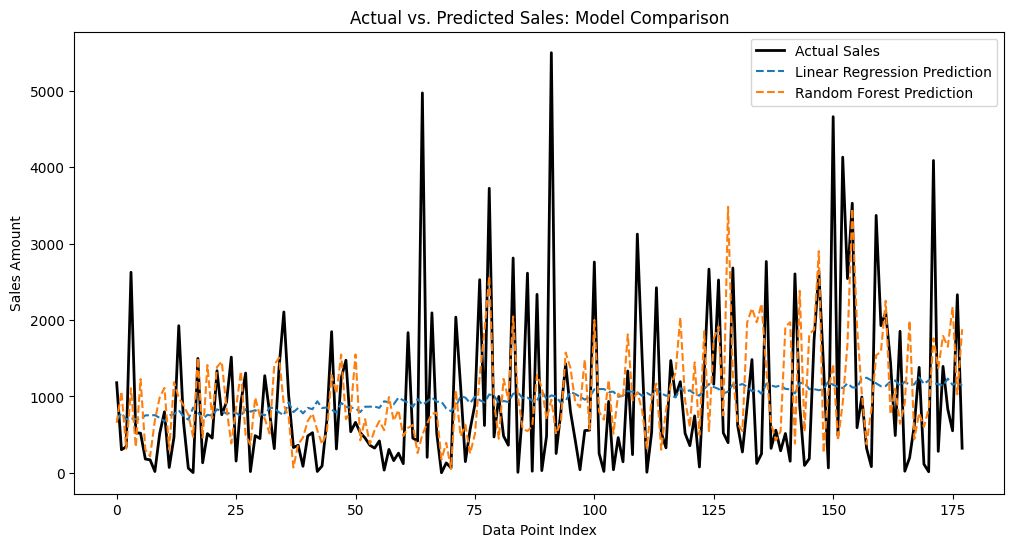

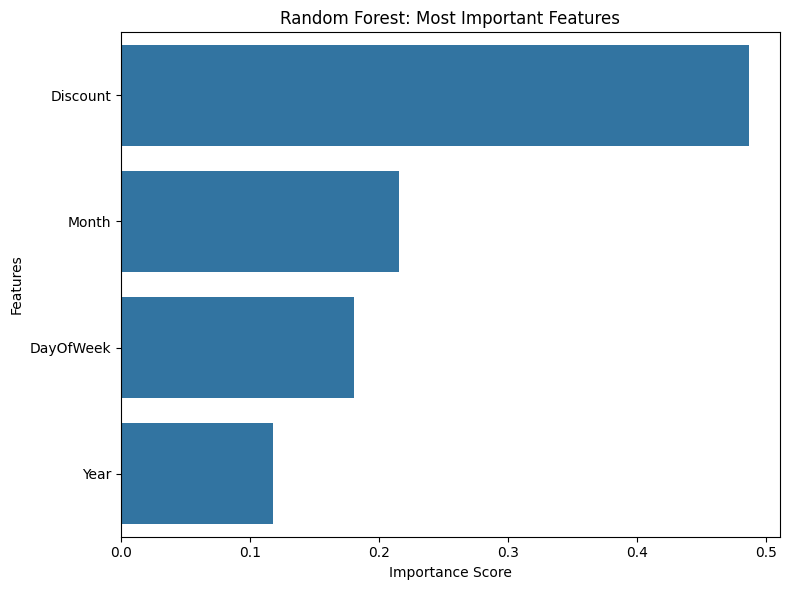

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load and Prepare
df = pd.read_csv('C:/Users/user/Downloads/stores_sales_forecasting.csv', encoding='latin1', on_bad_lines='skip')
df['Order Date'] = pd.to_datetime(df['Order Date'])
daily_sales = df.groupby('Order Date').agg({'Sales': 'sum', 'Discount': 'mean'}).reset_index()

# 2. Feature Engineering
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['DayOfWeek'] = daily_sales['Order Date'].dt.dayofweek

# 3. Define X and y
X = daily_sales[['Month', 'Year', 'DayOfWeek', 'Discount']]
y = daily_sales['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Train and Evaluate Both Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = model
    # Calculate all metrics
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse) # Calculating RMSE
    r2 = r2_score(y_test, preds)
    
    print(f"--- {name} Metrics ---")
    print(f"MAE:  ${mae:.2f}")
    print(f"MSE:  ${mse:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"R2 Score: {r2:.4f}\n")

# 5. Dynamic Future Prediction
print("--- Dynamic Forecasting ---")
m = int(input("Enter Month (1-12): "))
y_in = int(input("Enter Year (e.g., 2017): "))
dow = int(input("Enter Day of Week (0=Monday, 6=Sunday): "))
disc = float(input("Enter Discount (0.0 to 0.5): "))

user_data = pd.DataFrame({'Month': [m], 'Year': [y_in], 'DayOfWeek': [dow], 'Discount': [disc]})

# Calculate scores safely
score_rf = models["Random Forest"].score(X_test, y_test)
score_lr = models["Linear Regression"].score(X_test, y_test)

chosen_model_name = "Random Forest" if score_rf > score_lr else "Linear Regression"
final_pred = models[chosen_model_name].predict(user_data)

print(f"\nUsing {chosen_model_name} for prediction (Model R2 score: {max(score_rf, score_lr):.4f})")
print(f"Forecasted Sales: ${final_pred[0]:.2f}")
#matplotlib line plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Sales', color='black', linewidth=2)

for name, model in models.items():
    preds = model.predict(X_test)
    plt.plot(preds, label=f'{name} Prediction', linestyle='--')

# Adding labels
plt.title('Actual vs. Predicted Sales: Model Comparison')
plt.xlabel('Data Point Index') # Added Label
plt.ylabel('Sales Amount')     # Added Label
plt.legend()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure these lines are run to define feature_imp
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# 2. Now run the plotting code in the same cell
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_imp, y=feature_imp.index)

plt.title('Random Forest: Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()